# 06 - Texte : Modèles Avancés et Interprétabilité

## Objectif de ce notebook
Explorer les **ensembles de modèles** (Voting, Stacking), le **Deep Learning** (MLP, CNN, LSTM) et l'**interprétabilité** (SHAP, feature importance) pour finaliser la chaîne de classification texte.

**Prérequis** : Exécuter les notebooks 04 et 05 pour disposer des données et du meilleur modèle optimisé dans `models/`.

**Livrable** : Modèle final retenu, interprétabilité, analyse des erreurs et conclusions pour la classification de produits.

---

## Plan
1. Chargement des données et du meilleur modèle (notebook 05)
2. Ensembles avancés (Voting, Stacking)
3. Modèles Deep Learning (MLP, CNN, LSTM sur vecteurs TF-IDF)
4. Interprétabilité (SHAP, feature importance)
5. Comparaison finale de tous les modèles
6. Analyse des erreurs et confusions
7. Conclusions scientifiques et métiers
8. Sauvegarde du modèle final



In [1]:
# Import des bibliothèques nécessaires
import os
os.environ['OMP_NUM_THREADS'] = str(os.cpu_count() or 4)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
import pickle
warnings.filterwarnings('ignore')

# Ajouter le dossier src au path
sys.path.append(str(Path('../').resolve()))

# Import des modules
from src.utils.data_loader import load_data
from src.modeling import TFIDFVectorizer, AdvancedModels
from src.deep_learning import (
    create_mlp_model,
    create_cnn_model,
    create_lstm_model,
    train_neural_network
)
from src.interpretability import (
    plot_feature_importance,
    get_top_features,
    analyze_feature_importance,
    explain_model_with_shap,
    plot_shap_summary,
    plot_shap_waterfall
)
from src.evaluation import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix
)

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import classification_report

# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Bibliothèques importées avec succès")



✅ Bibliothèques importées avec succès


## 1. Chargement des Données et du Meilleur Modèle

Chargement des données et du meilleur modèle optimisé (notebook 05).


In [2]:
# Chemins
DATA_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')

# Chargement des données
print("🔄 Chargement des données...")
X_train = pd.read_csv(DATA_DIR / 'X_train_clean.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test_clean.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv')

# Chargement optionnel : y_train_superclass (24 classes)
y_train_superclass = None
y_train_superclass_path = DATA_DIR / 'y_train_superclass.csv'
if y_train_superclass_path.exists():
    y_train_superclass = pd.read_csv(y_train_superclass_path)
else:
    # Recréer la superclasse si le fichier n'existe pas (Publications -> 9999)
    CODE_SUPERCLASSE = 9999
    PUBLICATIONS_CLASSES = {10, 2280, 2403, 2705}
    y_train_superclass = y_train.copy()
    y_train_superclass['prdtypecode'] = y_train['prdtypecode'].apply(
        lambda x: CODE_SUPERCLASSE if x in PUBLICATIONS_CLASSES else x
    )
    y_train_superclass.to_csv(y_train_superclass_path, index=False)
    print("⚠️ y_train_superclass.csv introuvable : superclasse recréée et sauvegardée.")

# Chargement du vectoriseur et des label encoders
print("🔄 Chargement du vectoriseur et des label encoders...")
vectorizer = TFIDFVectorizer.load(MODELS_DIR / 'tfidf_vectorizer.pkl')
with open(MODELS_DIR / 'label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

label_encoder_superclass = None
label_encoder_superclass_path = MODELS_DIR / 'label_encoder_superclass.pkl'
if label_encoder_superclass_path.exists():
    with open(label_encoder_superclass_path, 'rb') as f:
        label_encoder_superclass = pickle.load(f)

# Vectorisation
X_train_texts = X_train['text_combined'].astype(str)
X_test_texts = X_test['text_combined'].astype(str)
X_train_vect = vectorizer.transform(X_train_texts)
X_test_vect = vectorizer.transform(X_test_texts)

# Encodage des labels - 27 et 24 classes
y_train_labels = y_train['prdtypecode'].values
y_train_encoded = label_encoder.transform(y_train_labels)

y_train_encoded_sc = None
if y_train_superclass is not None:
    if label_encoder_superclass is None:
        label_encoder_superclass = LabelEncoder()
        label_encoder_superclass.fit(y_train_superclass['prdtypecode'].values)
        with open(label_encoder_superclass_path, 'wb') as f:
            pickle.dump(label_encoder_superclass, f)
    y_train_encoded_sc = label_encoder_superclass.transform(y_train_superclass['prdtypecode'].values)

# Scénarios
SCENARIOS = [("27 classes", y_train_encoded, label_encoder)]
if y_train_encoded_sc is not None:
    SCENARIOS.append(("24 classes (superclass)", y_train_encoded_sc, label_encoder_superclass))

# Division train/validation - mêmes indices pour les deux scénarios
indices = np.arange(len(y_train_encoded))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y_train_encoded)
X_train_split = X_train_vect[train_idx]
X_val_split = X_train_vect[val_idx]

splits_by_scenario = {name: (y_enc[train_idx], y_enc[val_idx]) for name, y_enc, _ in SCENARIOS}

# Chargement du meilleur modèle de Step 2 par scénario
print("🔄 Chargement du meilleur modèle de Step 2...")
best_model_step2_by_scenario = {}
metrics_step2_by_scenario = {}
y_pred_step2_by_scenario = {}

for scenario_name, _, _ in SCENARIOS:
    scenario_suffix = "superclass" if "superclass" in scenario_name.lower() else "27_classes"
    final_model_files = list(MODELS_DIR.glob(f"*_{scenario_suffix}_final.pkl"))
    if not final_model_files:
        final_model_files = list(MODELS_DIR.glob("*_final.pkl"))

    if final_model_files:
        with open(final_model_files[0], 'rb') as f:
            best_model_step2 = pickle.load(f)
        print(f"✅ Modèle chargé : {final_model_files[0].name} ({scenario_name})")

        y_train_split, y_val_split = splits_by_scenario[scenario_name]
        y_pred_step2 = best_model_step2.predict(X_val_split)
        metrics_step2 = evaluate_model(y_val_split, y_pred_step2)
        print(f"📊 Performances Step 2 ({scenario_name}) - F1-macro : {metrics_step2['f1_macro']:.4f}")

        best_model_step2_by_scenario[scenario_name] = best_model_step2
        metrics_step2_by_scenario[scenario_name] = metrics_step2
        y_pred_step2_by_scenario[scenario_name] = y_pred_step2
    else:
        print(f"⚠️  Aucun modèle final trouvé pour {scenario_name}. Utiliser le baseline.")
        best_model_step2_by_scenario[scenario_name] = None

print(f"\n✅ Données chargées et préparées !")
print(f"  - Train : {X_train_split.shape[0]:,} échantillons")
print(f"  - Validation : {X_val_split.shape[0]:,} échantillons")
print(f"  - Test : {X_test_vect.shape[0]:,} échantillons")
print(f"  - Vocabulaire : {vectorizer.get_vocabulary_size():,} mots")
print(f"✅ Scénarios à tester : {[s[0] for s in SCENARIOS]}")

label_encoder_by_scenario = {name: enc for name, _, enc in SCENARIOS}

# Scénario par défaut pour les cellules suivantes (compatibilité)
DEFAULT_SCENARIO = "27 classes"
y_train_split, y_val_split = splits_by_scenario[DEFAULT_SCENARIO]

best_model_step2 = best_model_step2_by_scenario.get(DEFAULT_SCENARIO)
metrics_step2 = metrics_step2_by_scenario.get(DEFAULT_SCENARIO)
y_pred_step2 = y_pred_step2_by_scenario.get(DEFAULT_SCENARIO)



🔄 Chargement des données...
🔄 Chargement du vectoriseur et des label encoders...
🔄 Chargement du meilleur modèle de Step 2...
✅ Modèle chargé : svm_linear_baseline_27_classes_final.pkl (27 classes)
📊 Performances Step 2 (27 classes) - F1-macro : 0.7847
✅ Modèle chargé : svm_linear_baseline_superclass_final.pkl (24 classes (superclass))
📊 Performances Step 2 (24 classes (superclass)) - F1-macro : 0.8145

✅ Données chargées et préparées !
  - Train : 67,932 échantillons
  - Validation : 16,984 échantillons
  - Test : 13,812 échantillons
  - Vocabulaire : 10,000 mots
✅ Scénarios à tester : ['27 classes', '24 classes (superclass)']


## 2. Ensembles Avancés (Voting et Stacking)

Création d'ensembles de modèles pour améliorer les performances.


In [3]:
# Ensembles - 27 et 24 classes
print("="*80)
print("ENSEMBLES DE MODÈLES (27 et 24 classes)")
print("="*80)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

base_models = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)),
    ('svm', LinearSVC(random_state=42, dual=False, max_iter=2000)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
]

metrics_voting_dict, metrics_stacking_dict = {}, {}
voting_clf_by_scenario = {}
stacking_clf_by_scenario = {}
y_pred_voting_by_scenario = {}
y_pred_stacking_by_scenario = {}

for scenario_name, _, _ in SCENARIOS:
    y_train_s, y_val_s = splits_by_scenario[scenario_name]
    print(f"\n🔄 {scenario_name} : Voting + Stacking...")

    vc = VotingClassifier(estimators=base_models, voting='hard', n_jobs=-1)
    vc.fit(X_train_split, y_train_s)
    y_pred_voting = vc.predict(X_val_split)
    metrics_voting_dict[scenario_name] = evaluate_model(y_val_s, y_pred_voting)

    sc = StackingClassifier(
        estimators=base_models,
        final_estimator=LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
        cv=3,
        n_jobs=-1
    )
    sc.fit(X_train_split, y_train_s)
    y_pred_stacking = sc.predict(X_val_split)
    metrics_stacking_dict[scenario_name] = evaluate_model(y_val_s, y_pred_stacking)

    voting_clf_by_scenario[scenario_name] = vc
    stacking_clf_by_scenario[scenario_name] = sc
    y_pred_voting_by_scenario[scenario_name] = y_pred_voting
    y_pred_stacking_by_scenario[scenario_name] = y_pred_stacking

    print(f"  Voting : {metrics_voting_dict[scenario_name]['f1_macro']:.4f} | Stacking : {metrics_stacking_dict[scenario_name]['f1_macro']:.4f}")

print(f"\n📊 Comparaison 27 vs 24 classes : Voting et Stacking")

# Variables par défaut (compatibilité)
voting_clf = voting_clf_by_scenario.get(DEFAULT_SCENARIO)
stacking_clf = stacking_clf_by_scenario.get(DEFAULT_SCENARIO)
y_pred_voting = y_pred_voting_by_scenario.get(DEFAULT_SCENARIO)
y_pred_stacking = y_pred_stacking_by_scenario.get(DEFAULT_SCENARIO)
metrics_voting = metrics_voting_dict.get(DEFAULT_SCENARIO)
metrics_stacking = metrics_stacking_dict.get(DEFAULT_SCENARIO)



ENSEMBLES DE MODÈLES (27 et 24 classes)

🔄 27 classes : Voting + Stacking...
  Voting : 0.7895 | Stacking : 0.8021

🔄 24 classes (superclass) : Voting + Stacking...
  Voting : 0.8128 | Stacking : 0.8306

📊 Comparaison 27 vs 24 classes : Voting et Stacking


## 3. Modèles Deep Learning

Test de modèles de Deep Learning : MLP, CNN, LSTM.


In [4]:
# Test des modèles Deep Learning
print("="*80)
print("MODÈLES DEEP LEARNING")
print("="*80)

# Convertir les matrices creuses en denses pour TensorFlow
X_train_dense = X_train_split.toarray() if hasattr(X_train_split, 'toarray') else X_train_split
X_val_dense = X_val_split.toarray() if hasattr(X_val_split, 'toarray') else X_val_split

input_dim = X_train_dense.shape[1]
print(f"  - Dimension d'entrée : {input_dim}")

mlp_results_by_scenario = {}
metrics_mlp_by_scenario = {}
y_pred_mlp_by_scenario = {}

for scenario_name, _, enc in SCENARIOS:
    y_train_s, y_val_s = splits_by_scenario[scenario_name]
    num_classes = len(enc.classes_)
    print(f"  - Nombre de classes ({scenario_name}) : {num_classes}")

    # MLP
    print(f"\n🔄 Entraînement MLP - {scenario_name}...")
    mlp_model = create_mlp_model(
        input_dim=input_dim,
        num_classes=num_classes,
        hidden_layers=[256, 128, 64],
        dropout_rate=0.3
    )

    mlp_results = train_neural_network(
        mlp_model,
        X_train_dense,
        y_train_s,
        X_val_dense,
        y_val_s,
        epochs=20,
        batch_size=128,
        verbose=1,
        early_stopping=True,
        patience=5
    )

    y_pred_mlp = np.argmax(mlp_results['model'].predict(X_val_dense, verbose=0), axis=1)
    metrics_mlp = evaluate_model(y_val_s, y_pred_mlp)

    mlp_results_by_scenario[scenario_name] = mlp_results
    metrics_mlp_by_scenario[scenario_name] = metrics_mlp
    y_pred_mlp_by_scenario[scenario_name] = y_pred_mlp

    print(f"✅ MLP ({scenario_name}) - F1-macro : {metrics_mlp['f1_macro']:.4f}")

# Variables par défaut (compatibilité)
mlp_results = mlp_results_by_scenario.get(DEFAULT_SCENARIO)
metrics_mlp = metrics_mlp_by_scenario.get(DEFAULT_SCENARIO)
y_pred_mlp = y_pred_mlp_by_scenario.get(DEFAULT_SCENARIO)



MODÈLES DEEP LEARNING
  - Dimension d'entrée : 10000
  - Nombre de classes (27 classes) : 27

🔄 Entraînement MLP - 27 classes...
🔄 Entraînement du modèle neural...
Epoch 1/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5951 - loss: 1.4425 - val_accuracy: 0.7705 - val_loss: 0.7823
Epoch 2/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7751 - loss: 0.7751 - val_accuracy: 0.7864 - val_loss: 0.7160
Epoch 3/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8196 - loss: 0.6149 - val_accuracy: 0.7933 - val_loss: 0.7044
Epoch 4/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8474 - loss: 0.5129 - val_accuracy: 0.7942 - val_loss: 0.7232
Epoch 5/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8694 - loss: 0.4375 - val_accuracy: 0.7932 - val_loss: 0.7602
Epoch 6/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8844 - loss: 0.3804 - val_accuracy: 0.7952 - val_loss: 0.7963
Epoch 7/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.89

In [5]:
# CNN (optionnel - peut être long)
print("\n🔄 Entraînement CNN...")
USE_CNN = True  # Mettre à False pour sauter

cnn_results_by_scenario = {}
metrics_cnn_by_scenario = {}
y_pred_cnn_by_scenario = {}

if USE_CNN:
    for scenario_name, _, enc in SCENARIOS:
        y_train_s, y_val_s = splits_by_scenario[scenario_name]
        num_classes = len(enc.classes_)

        print(f"\n🔄 Entraînement CNN - {scenario_name}...")
        cnn_model = create_cnn_model(
            input_dim=input_dim,
            num_classes=num_classes,
            filters=[64, 128],
            kernel_sizes=[3, 3],
            dense_units=64
        )

        cnn_results = train_neural_network(
            cnn_model,
            X_train_dense,
            y_train_s,
            X_val_dense,
            y_val_s,
            epochs=15,
            batch_size=128,
            verbose=1,
            early_stopping=True,
            patience=5
        )

        y_pred_cnn = np.argmax(cnn_results['model'].predict(X_val_dense, verbose=0), axis=1)
        metrics_cnn = evaluate_model(y_val_s, y_pred_cnn)

        cnn_results_by_scenario[scenario_name] = cnn_results
        metrics_cnn_by_scenario[scenario_name] = metrics_cnn
        y_pred_cnn_by_scenario[scenario_name] = y_pred_cnn

        print(f"✅ CNN ({scenario_name}) - F1-macro : {metrics_cnn['f1_macro']:.4f}")
else:
    print("CNN désactivé pour cette exécution")

# Variables par défaut (compatibilité)
cnn_results = cnn_results_by_scenario.get(DEFAULT_SCENARIO)
metrics_cnn = metrics_cnn_by_scenario.get(DEFAULT_SCENARIO)
y_pred_cnn = y_pred_cnn_by_scenario.get(DEFAULT_SCENARIO)




🔄 Entraînement CNN...

🔄 Entraînement CNN - 27 classes...
🔄 Entraînement du modèle neural...
Epoch 1/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 192s 361ms/step - accuracy: 0.6788 - loss: 1.1685 - val_accuracy: 0.7711 - val_loss: 0.7593
Epoch 2/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 191s 360ms/step - accuracy: 0.7858 - loss: 0.7148 - val_accuracy: 0.7911 - val_loss: 0.6874
Epoch 3/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 191s 359ms/step - accuracy: 0.8238 - loss: 0.5676 - val_accuracy: 0.7933 - val_loss: 0.6987
Epoch 4/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 191s 360ms/step - accuracy: 0.8502 - loss: 0.4716 - val_accuracy: 0.7949 - val_loss: 0.7177
Epoch 5/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 191s 359ms/step - accuracy: 0.8666 - loss: 0.4133 - val_accuracy: 0.7960 - val_loss: 0.7374
Epoch 6/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 191s 360ms/step - accuracy: 0.8795 - loss: 0.3708 - val_accuracy: 0.7942 - val_loss: 0.7880
Epoch 7/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 193s 363ms/step - accuracy: 0.8886 - loss: 0.3380 - val_accuracy: 0.7932 -

## 4. Interprétabilité des Modèles

Analyse de l'importance des features et explication des prédictions avec SHAP.


ANALYSE DE L'IMPORTANCE DES FEATURES

🔄 Analyse de l'importance des features pour Meilleur modèle Step 2...

📊 Top 10 features les plus importantes :
   1. générique                                          : 2.131675
   2. piscine                                            : 1.329227
   3. stream                                             : 1.210015
   4. sweetheart93                                       : 1.182709
   5. magideal                                           : 1.146578
   6. figurine                                           : 0.935630
   7. jeu                                                : 0.875609
   8. lot                                                : 0.864001
   9. magideal description                               : 0.861327
  10. jeux                                               : 0.826810


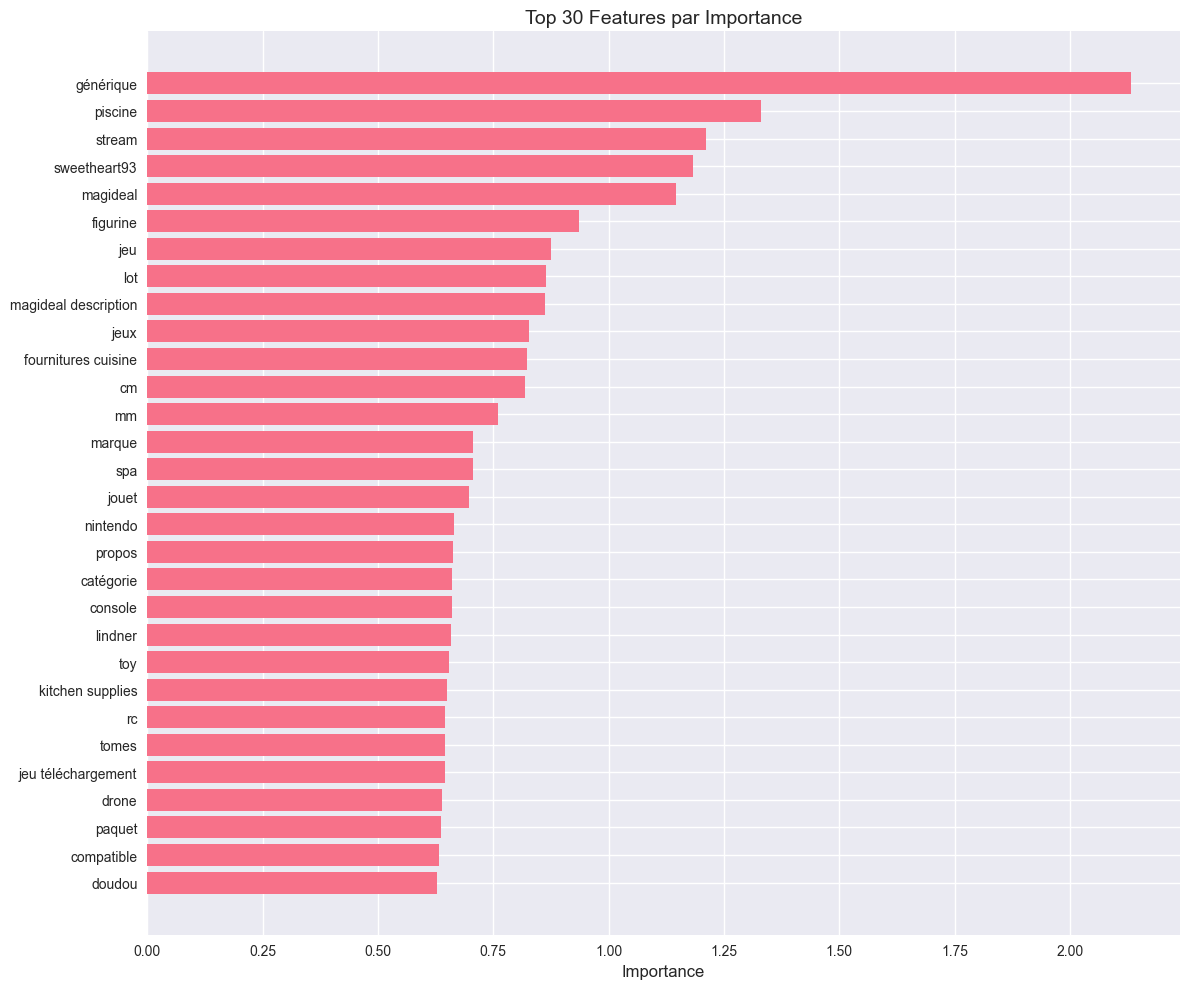

In [6]:
# Analyse de l'importance des features
print("="*80)
print("ANALYSE DE L'IMPORTANCE DES FEATURES")
print("="*80)

# Utiliser le meilleur modèle (Step 2 ou Voting/Stacking)
if best_model_step2:
    model_to_analyze = best_model_step2
    model_name = "Meilleur modèle Step 2"
else:
    model_to_analyze = voting_clf
    model_name = "Voting Classifier"

# Récupérer les noms des features (mots du vocabulaire)
feature_names = vectorizer.get_feature_names_out().tolist()

# Analyser l'importance
print(f"\n🔄 Analyse de l'importance des features pour {model_name}...")
importance_results = analyze_feature_importance(
    model_to_analyze,
    feature_names=feature_names,
    top_n=30
)

if importance_results:
    print(f"\n📊 Top 10 features les plus importantes :")
    for i, (feature, importance) in enumerate(importance_results['top_features'][:10], 1):
        print(f"  {i:2d}. {feature[:50]:50s} : {importance:.6f}")
    
    # Visualisation
    plot_feature_importance(
        importance_results['feature_importance'],
        top_n=30,
        figsize=(12, 10)
    )
else:
    print("⚠️  Impossible d'analyser l'importance des features pour ce modèle")



In [7]:
# Analyse SHAP (optionnel - peut être long)
print("="*80)
print("ANALYSE SHAP")
print("="*80)

USE_SHAP = False  # Mettre à True pour activer SHAP (peut être très long)

if USE_SHAP:
    # Échantillonner pour accélérer
    sample_size = min(100, len(X_val_split))
    indices = np.random.choice(len(X_val_split), sample_size, replace=False)
    X_sample = X_val_split[indices].toarray() if hasattr(X_val_split, 'toarray') else X_val_split[indices]
    
    print(f"🔄 Calcul des valeurs SHAP sur {sample_size} échantillons...")
    shap_values = explain_model_with_shap(
        model_to_analyze,
        X_sample,
        feature_names=feature_names[:1000],  # Limiter pour accélérer
        max_samples=sample_size
    )
    
    # Résumé SHAP
    plot_shap_summary(shap_values, max_display=20)
    
    # Waterfall pour une instance
    plot_shap_waterfall(shap_values, instance_idx=0, max_display=10)
else:
    print("SHAP désactivé pour cette exécution (peut être activé en mettant USE_SHAP = True)")
    print("Note : SHAP peut être très long sur de gros datasets")



ANALYSE SHAP
SHAP désactivé pour cette exécution (peut être activé en mettant USE_SHAP = True)
Note : SHAP peut être très long sur de gros datasets


## 5. Comparaison Finale de Tous les Modèles

Comparaison de tous les modèles testés (Step 2, Ensembles, Deep Learning).


COMPARAISON FINALE DE TOUS LES MODÈLES

📊 Résultats finaux (triés par F1-macro) :
               Scenario                Model  F1_macro  F1_weighted  Accuracy
24 classes (superclass)  Stacking Classifier  0.830592     0.857938  0.860045
24 classes (superclass)        Step 2 (Best)  0.814468     0.845208  0.848504
24 classes (superclass)    Voting Classifier  0.812842     0.843020  0.846856
24 classes (superclass) MLP (Neural Network)  0.801198     0.836071  0.839614
24 classes (superclass)                  CNN  0.799184     0.832693  0.834786
             27 classes  Stacking Classifier  0.802137     0.816121  0.815061
             27 classes    Voting Classifier  0.789507     0.805276  0.804816
             27 classes        Step 2 (Best)  0.784744     0.801488  0.802285
             27 classes MLP (Neural Network)  0.772813     0.792906  0.793335
             27 classes                  CNN  0.771815     0.790042  0.791098

-----------------------------------------------------------

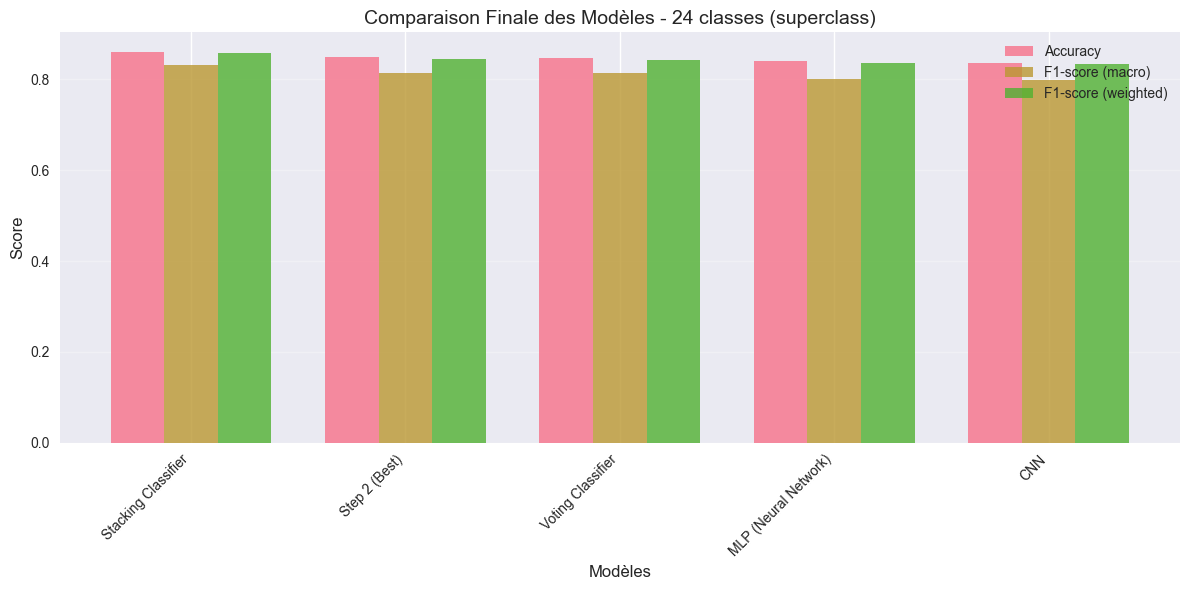

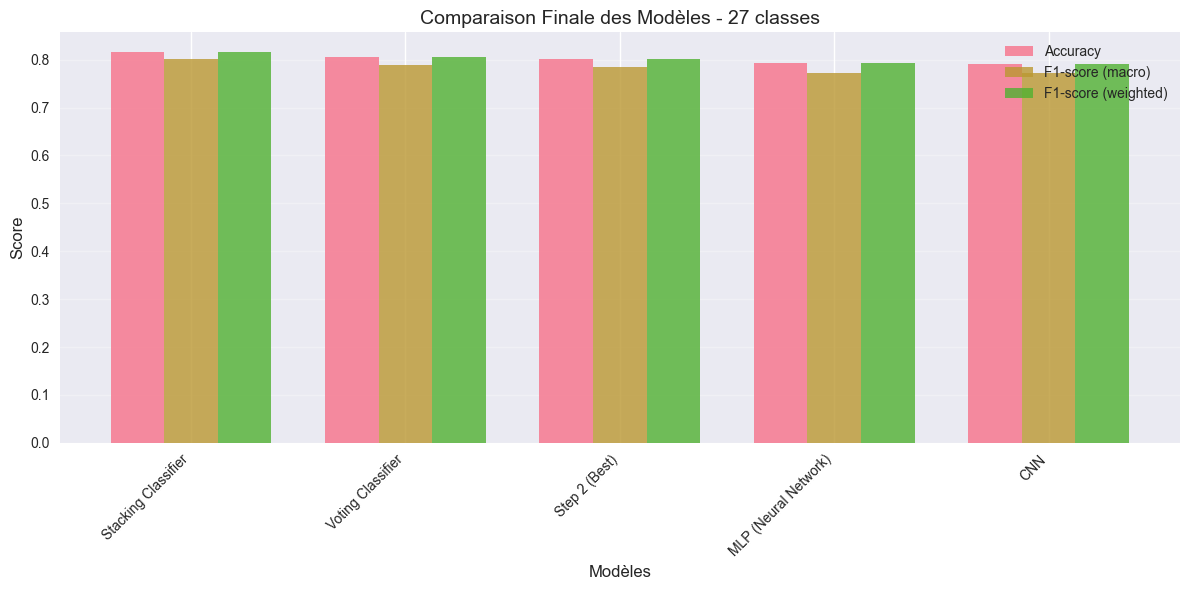

In [8]:
# Comparaison finale
print("="*80)
print("COMPARAISON FINALE DE TOUS LES MODÈLES")
print("="*80)

final_results = []

for scenario_name, _, _ in SCENARIOS:
    # Modèle Step 2
    metrics_step2_s = metrics_step2_by_scenario.get(scenario_name)
    if metrics_step2_s:
        final_results.append({
            'Scenario': scenario_name,
            'Model': 'Step 2 (Best)',
            'F1_macro': metrics_step2_s['f1_macro'],
            'F1_weighted': metrics_step2_s['f1_weighted'],
            'Accuracy': metrics_step2_s['accuracy']
        })

    # Ensembles
    metrics_voting_s = metrics_voting_dict.get(scenario_name)
    if metrics_voting_s:
        final_results.append({
            'Scenario': scenario_name,
            'Model': 'Voting Classifier',
            'F1_macro': metrics_voting_s['f1_macro'],
            'F1_weighted': metrics_voting_s['f1_weighted'],
            'Accuracy': metrics_voting_s['accuracy']
        })

    metrics_stacking_s = metrics_stacking_dict.get(scenario_name)
    if metrics_stacking_s:
        final_results.append({
            'Scenario': scenario_name,
            'Model': 'Stacking Classifier',
            'F1_macro': metrics_stacking_s['f1_macro'],
            'F1_weighted': metrics_stacking_s['f1_weighted'],
            'Accuracy': metrics_stacking_s['accuracy']
        })

    # Deep Learning
    metrics_mlp_s = metrics_mlp_by_scenario.get(scenario_name)
    if metrics_mlp_s:
        final_results.append({
            'Scenario': scenario_name,
            'Model': 'MLP (Neural Network)',
            'F1_macro': metrics_mlp_s['f1_macro'],
            'F1_weighted': metrics_mlp_s['f1_weighted'],
            'Accuracy': metrics_mlp_s['accuracy']
        })

    metrics_cnn_s = metrics_cnn_by_scenario.get(scenario_name)
    if metrics_cnn_s:
        final_results.append({
            'Scenario': scenario_name,
            'Model': 'CNN',
            'F1_macro': metrics_cnn_s['f1_macro'],
            'F1_weighted': metrics_cnn_s['f1_weighted'],
            'Accuracy': metrics_cnn_s['accuracy']
        })

# DataFrame de comparaison
final_comparison = pd.DataFrame(final_results).sort_values(['Scenario', 'F1_macro'], ascending=[True, False])

print("\n📊 Résultats finaux (triés par F1-macro) :")
print("="*80)
print(final_comparison.to_string(index=False))

# Tableaux séparés par scénario
for scenario in final_comparison['Scenario'].unique():
    print(f"\n{'-'*80}")
    print(f"TABLEAU RÉSULTATS - {scenario}")
    print(f"{'-'*80}")
    scenario_df = final_comparison[final_comparison['Scenario'] == scenario]
    print(scenario_df.to_string(index=False))

# Visualisation par scénario
for scenario in final_comparison['Scenario'].unique():
    scenario_df = final_comparison[final_comparison['Scenario'] == scenario]
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(scenario_df))
    width = 0.25

    ax.bar(x - width, scenario_df['Accuracy'], width, label='Accuracy', alpha=0.8)
    ax.bar(x, scenario_df['F1_macro'], width, label='F1-score (macro)', alpha=0.8)
    ax.bar(x + width, scenario_df['F1_weighted'], width, label='F1-score (weighted)', alpha=0.8)

    ax.set_xlabel('Modèles', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'Comparaison Finale des Modèles - {scenario}', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(scenario_df['Model'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()



MEILLEUR MODÈLE FINAL - 24 classes (superclass)
🏆 Modèle : Stacking Classifier
   F1-score (macro) : 0.8306

RAPPORT DE CLASSIFICATION - Stacking Classifier (24 classes (superclass))
RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

   Classe 40       0.79      0.62      0.69       502
   Classe 50       0.83      0.82      0.82       336
   Classe 60       0.95      0.87      0.91       166
 Classe 1140       0.77      0.76      0.77       534
 Classe 1160       0.93      0.89      0.91       791
 Classe 1180       0.75      0.51      0.61       153
 Classe 1280       0.71      0.73      0.72       974
 Classe 1281       0.66      0.52      0.58       414
 Classe 1300       0.93      0.92      0.92      1009
 Classe 1301       0.94      0.93      0.94       161
 Classe 1302       0.85      0.77      0.80       498
 Classe 1320       0.79      0.78      0.79       648
 Classe 1560       0.85      0.85      0.85      1015
 Classe 1920       0.90      0.91 

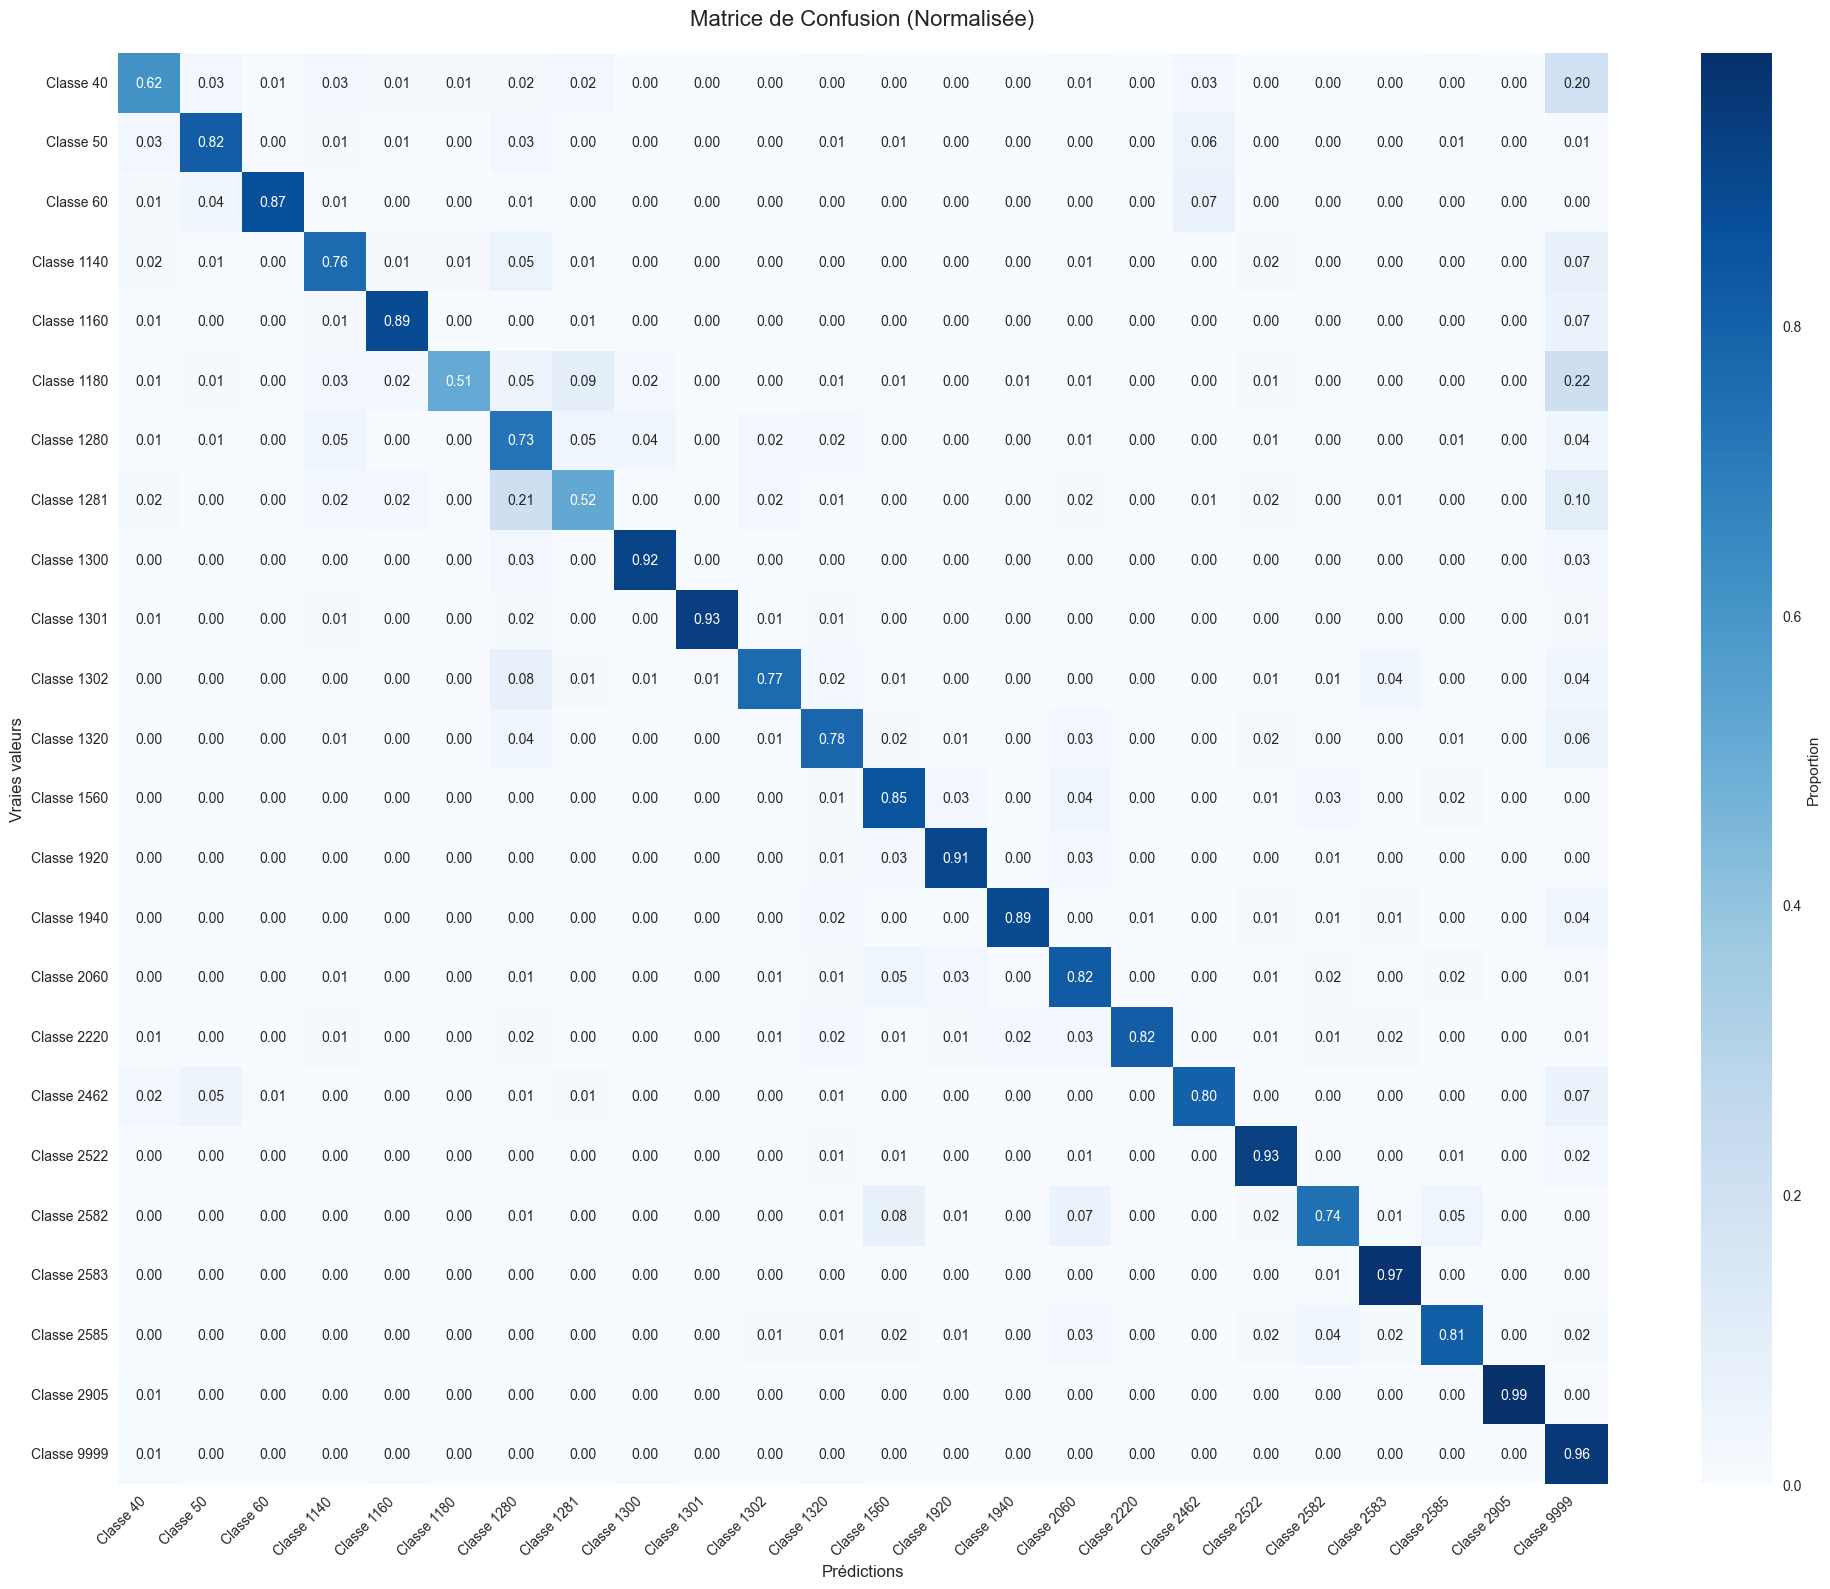


📊 Top 10 confusions les plus fréquentes (24 classes (superclass)) :
  40 → 9999 : 101 fois
  1281 → 1280 : 89 fois
  1160 → 9999 : 54 fois
  2060 → 1560 : 48 fois
  1280 → 1140 : 46 fois
  1560 → 2060 : 44 fois
  1280 → 1281 : 44 fois
  1280 → 9999 : 41 fois
  2582 → 1560 : 41 fois
  1281 → 9999 : 41 fois
MEILLEUR MODÈLE FINAL - 27 classes
🏆 Modèle : Stacking Classifier
   F1-score (macro) : 0.8021

RAPPORT DE CLASSIFICATION - Stacking Classifier (27 classes)
RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

   Classe 10       0.43      0.58      0.49       623
   Classe 40       0.74      0.63      0.68       502
   Classe 50       0.83      0.83      0.83       336
   Classe 60       0.95      0.87      0.91       166
 Classe 1140       0.76      0.76      0.76       534
 Classe 1160       0.91      0.89      0.90       791
 Classe 1180       0.71      0.52      0.60       153
 Classe 1280       0.71      0.72      0.72       974
 Classe 1281       0.6

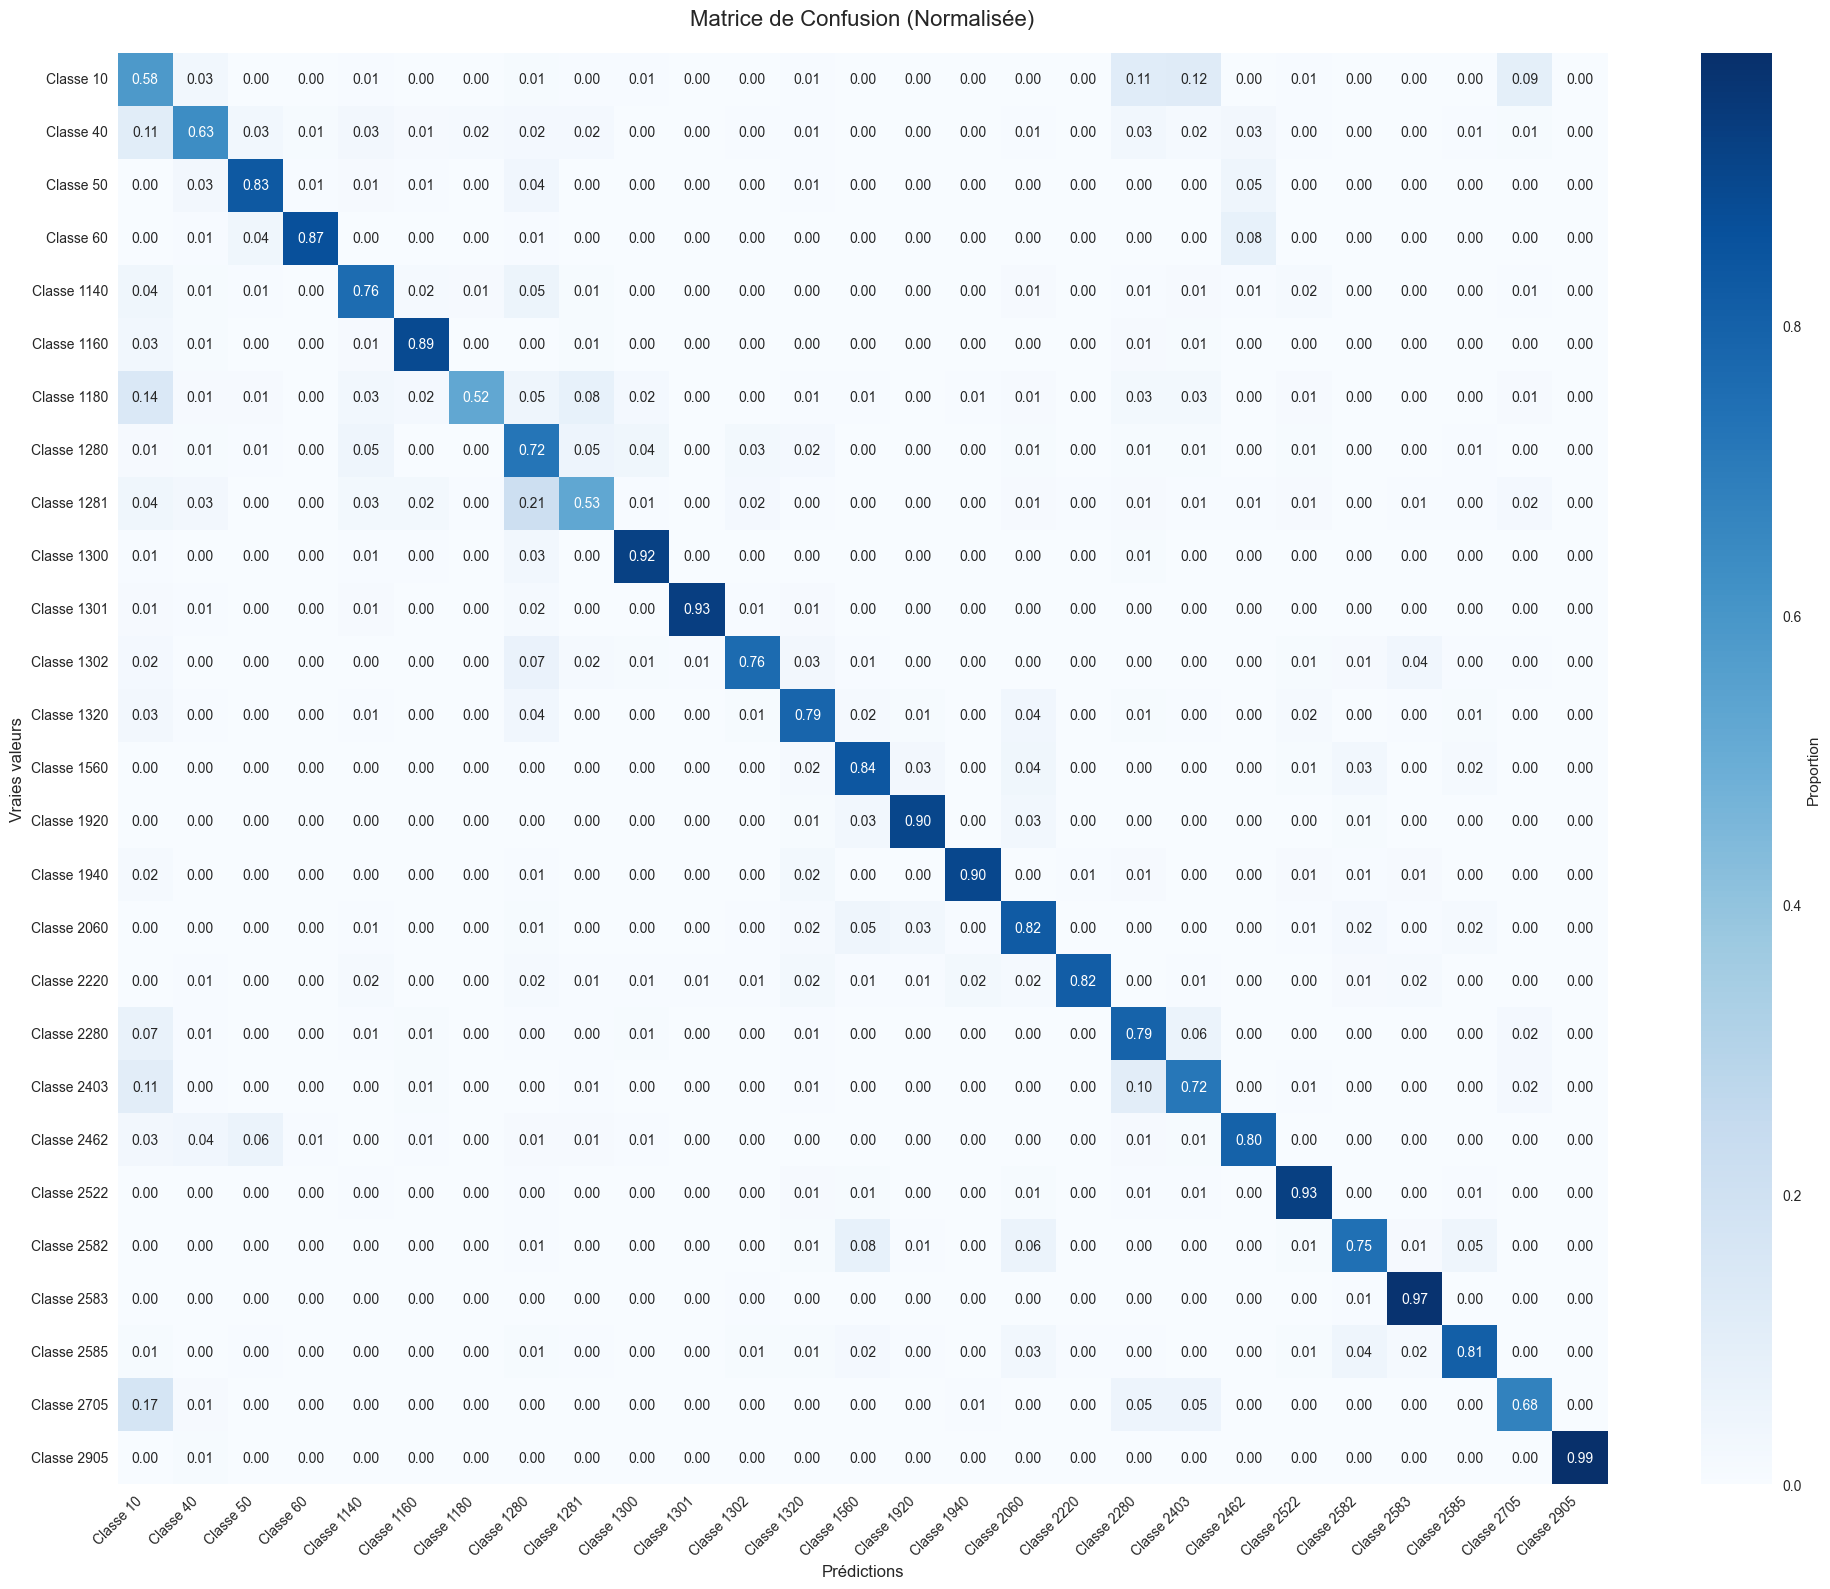


📊 Top 10 confusions les plus fréquentes (27 classes) :
  2403 → 10 : 101 fois
  2403 → 2280 : 100 fois
  2705 → 10 : 95 fois
  1281 → 1280 : 89 fois
  10 → 2403 : 76 fois
  10 → 2280 : 71 fois
  2280 → 10 : 69 fois
  10 → 2705 : 59 fois
  2280 → 2403 : 56 fois
  40 → 10 : 55 fois


In [9]:
# Identification du meilleur modèle final
best_final_by_scenario = {}

for scenario in final_comparison['Scenario'].unique():
    scenario_df = final_comparison[final_comparison['Scenario'] == scenario]
    best_final_model_name = scenario_df.iloc[0]['Model']
    best_final_f1 = scenario_df.iloc[0]['F1_macro']

    print("="*80)
    print(f"MEILLEUR MODÈLE FINAL - {scenario}")
    print("="*80)
    print(f"🏆 Modèle : {best_final_model_name}")
    print(f"   F1-score (macro) : {best_final_f1:.4f}")

    # Récupération du meilleur modèle et prédictions
    if best_final_model_name == 'Step 2 (Best)':
        best_final_model = best_model_step2_by_scenario.get(scenario)
        y_pred_final = y_pred_step2_by_scenario.get(scenario)
    elif best_final_model_name == 'Voting Classifier':
        best_final_model = voting_clf_by_scenario.get(scenario)
        y_pred_final = y_pred_voting_by_scenario.get(scenario)
    elif best_final_model_name == 'Stacking Classifier':
        best_final_model = stacking_clf_by_scenario.get(scenario)
        y_pred_final = y_pred_stacking_by_scenario.get(scenario)
    elif best_final_model_name == 'MLP (Neural Network)':
        best_final_model = mlp_results_by_scenario.get(scenario, {}).get('model')
        y_pred_final = y_pred_mlp_by_scenario.get(scenario)
    else:
        best_final_model = cnn_results_by_scenario.get(scenario, {}).get('model')
        y_pred_final = y_pred_cnn_by_scenario.get(scenario)

    y_train_s, y_val_s = splits_by_scenario[scenario]
    label_encoder_s = label_encoder_by_scenario[scenario]

    # Rapport de classification
    print(f"\n{'='*80}")
    print(f"RAPPORT DE CLASSIFICATION - {best_final_model_name} ({scenario})")
    print(f"{'='*80}")
    class_names = [f"Classe {cls}" for cls in sorted(label_encoder_s.classes_)]
    print_classification_report(y_val_s, y_pred_final, target_names=class_names)

    # Matrice de confusion
    plot_confusion_matrix(
        y_val_s,
        y_pred_final,
        class_names=class_names,
        figsize=(20, 16),
        normalize=True
    )

    # Analyse des confusions
    errors_mask = y_val_s != y_pred_final
    confusion_pairs = []
    for true_label, pred_label in zip(y_val_s[errors_mask], y_pred_final[errors_mask]):
        true_class = label_encoder_s.inverse_transform([true_label])[0]
        pred_class = label_encoder_s.inverse_transform([pred_label])[0]
        confusion_pairs.append((true_class, pred_class))

    if confusion_pairs:
        confusion_df = pd.Series(confusion_pairs).value_counts().head(10)
        print(f"\n📊 Top 10 confusions les plus fréquentes ({scenario}) :")
        for (true_class, pred_class), count in confusion_df.items():
            print(f"  {true_class} → {pred_class} : {count} fois")
    else:
        print(f"\n📊 Aucune confusion détectée ({scenario})")

    best_final_by_scenario[scenario] = {
        'model_name': best_final_model_name,
        'model': best_final_model,
        'y_val': y_val_s,
        'y_pred': y_pred_final,
        'label_encoder': label_encoder_s
    }

# Variables par défaut (compatibilité)
best_final_model_name = best_final_by_scenario.get(DEFAULT_SCENARIO, {}).get('model_name')
best_final_model = best_final_by_scenario.get(DEFAULT_SCENARIO, {}).get('model')
y_pred_final = best_final_by_scenario.get(DEFAULT_SCENARIO, {}).get('y_pred')



## 7. Conclusions Scientifiques et Métiers

Analyse des résultats et conclusions pour le projet.


In [10]:
print("="*80)
print("CONCLUSIONS SCIENTIFIQUES ET MÉTIERS")
print("="*80)
print("\n✅ Recommandation : sauf contrainte métier forte, regrouper les classes améliore la performance.")

# Choix du scénario pour l'analyse (priorité à 24 classes)
scenario_for_analysis = "24 classes (superclass)" if "24 classes (superclass)" in best_final_by_scenario else DEFAULT_SCENARIO
analysis_info = best_final_by_scenario[scenario_for_analysis]

best_final_model_name = analysis_info['model_name']
y_val_analysis = analysis_info['y_val']
y_pred_analysis = analysis_info['y_pred']

# Performances finales
final_metrics = evaluate_model(y_val_analysis, y_pred_analysis)
baseline_f1_map = {
    "27 classes": 0.7843  # F1-macro baseline de Step 1 (27 classes)
}
baseline_f1 = baseline_f1_map.get(scenario_for_analysis)

print(f"\n📊 PERFORMANCES FINALES ({scenario_for_analysis})")
print(f"  - Modèle : {best_final_model_name}")
print(f"  - F1-score (macro) : {final_metrics['f1_macro']:.4f}")
print(f"  - F1-score (weighted) : {final_metrics['f1_weighted']:.4f}")
print(f"  - Accuracy : {final_metrics['accuracy']:.4f}")
if baseline_f1 is not None:
    print(f"  - Amélioration vs Baseline : {(final_metrics['f1_macro'] - baseline_f1) / baseline_f1 * 100:+.2f}%")
else:
    print("  - Amélioration vs Baseline : n/a")

# Analyse par classe
report = classification_report(y_val_analysis, y_pred_analysis, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).transpose()

# Classes les plus difficiles
difficult_classes = df_report.nsmallest(6, 'f1-score').tail(5)
print(f"\n⚠️  CLASSES LES PLUS DIFFICILES (F1-score < 0.5) :")
for idx, row in difficult_classes.iterrows():
    if idx not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"  - Classe {idx} : F1={row['f1-score']:.3f}, Precision={row['precision']:.3f}, Recall={row['recall']:.3f}")

# Classes performantes
good_classes = df_report.nlargest(6, 'f1-score').head(5)
print(f"\n✅ CLASSES LES MIEUX CLASSIFIÉES (F1-score > 0.9) :")
for idx, row in good_classes.iterrows():
    if idx not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"  - Classe {idx} : F1={row['f1-score']:.3f}, Precision={row['precision']:.3f}, Recall={row['recall']:.3f}")



CONCLUSIONS SCIENTIFIQUES ET MÉTIERS

✅ Recommandation : sauf contrainte métier forte, regrouper les classes améliore la performance.

📊 PERFORMANCES FINALES (24 classes (superclass))
  - Modèle : Stacking Classifier
  - F1-score (macro) : 0.8306
  - F1-score (weighted) : 0.8579
  - Accuracy : 0.8600
  - Amélioration vs Baseline : n/a

⚠️  CLASSES LES PLUS DIFFICILES (F1-score < 0.5) :
  - Classe 5 : F1=0.607, Precision=0.750, Recall=0.510
  - Classe 0 : F1=0.693, Precision=0.789, Recall=0.618
  - Classe 6 : F1=0.719, Precision=0.711, Recall=0.728
  - Classe 19 : F1=0.764, Precision=0.789, Recall=0.741
  - Classe 3 : F1=0.767, Precision=0.770, Recall=0.764

✅ CLASSES LES MIEUX CLASSIFIÉES (F1-score > 0.9) :
  - Classe 22 : F1=0.994, Precision=1.000, Recall=0.989
  - Classe 20 : F1=0.974, Precision=0.973, Recall=0.975
  - Classe 9 : F1=0.938, Precision=0.943, Recall=0.932
  - Classe 8 : F1=0.923, Precision=0.930, Recall=0.917
  - Classe 18 : F1=0.921, Precision=0.912, Recall=0.930


### Matrice de confusion détaillée : classes Publications (10, 2280, 2403, 2705)

In [11]:
# Confusions entre les 4 classes Publications (10, 2280, 2403, 2705)
from sklearn.metrics import confusion_matrix

# Cette analyse n'est pertinente qu'en 27 classes
scenario_for_analysis = "27 classes" if "27 classes" in best_final_by_scenario else DEFAULT_SCENARIO
analysis_info = best_final_by_scenario.get(scenario_for_analysis, {})

if scenario_for_analysis != "27 classes":
    print("Analyse Publications : non pertinente en 24 classes (fusion en superclasse).")
else:
    PUBLICATION_CLASSES = [10, 2280, 2403, 2705]
    CLASS_LABELS = {10: "Livres", 2280: "Presse", 2403: "BD/Partitions", 2705: "Romans"}

    y_val_analysis = analysis_info['y_val']
    y_pred_analysis = analysis_info['y_pred']
    label_encoder = analysis_info['label_encoder']

    cm = confusion_matrix(y_val_analysis, y_pred_analysis)
    # Mapping: index i -> prdtypecode
    idx_to_code = {i: label_encoder.classes_[i] for i in range(len(label_encoder.classes_))}
    code_to_idx = {c: i for i, c in enumerate(label_encoder.classes_)}

    # Extraire la sous-matrice pour les 4 classes
    indices = [code_to_idx[c] for c in PUBLICATION_CLASSES if c in code_to_idx]
    sub_cm = cm[np.ix_(indices, indices)]
    codes_sub = [c for c in PUBLICATION_CLASSES if c in code_to_idx]

    # Tableau : Vrai \ Prédit, avec effectifs et %
    print("="*90)
    print("MATRICE DE CONFUSION - CLASSES PUBLICATIONS")
    print("(Ligne = vraie classe, Colonne = prédite)")
    print("="*90)
    header = "Vrai \\ Prédit"
    print(f"\n{header:<20}", end="")
    for c in codes_sub:
        print(f"{CLASS_LABELS.get(c,c):>12}", end="")
    print(f"{'Total':>10}")
    print("-"*70)

    for i, true_c in enumerate(codes_sub):
        row = sub_cm[i]
        total = row.sum()
        print(f"{CLASS_LABELS.get(true_c,true_c):<20}", end="")
        for j, pred_c in enumerate(codes_sub):
            cnt = sub_cm[i, j]
            pct = 100 * cnt / total if total > 0 else 0
            s = f"{cnt} ({pct:.1f}%)" if true_c != pred_c or cnt > 0 else "-"
            print(f"{s:>12}", end="")
        print(f"{int(total):>10}")

    # % de mal classés dans une autre classe du groupe
    print("\n" + "="*90)
    print("Taux de confusion (vrais positifs exclus) :")
    for i, true_c in enumerate(codes_sub):
        row = sub_cm[i]
        total = row.sum()
        correct = sub_cm[i, i]
        wrong_in_group = total - correct
        pct_wrong = 100 * wrong_in_group / total if total > 0 else 0
        print(f"  Classe {true_c} ({CLASS_LABELS.get(true_c,true_c)}): {wrong_in_group}/{int(total)} mal classés = {pct_wrong:.1f}%")

MATRICE DE CONFUSION - CLASSES PUBLICATIONS
(Ligne = vraie classe, Colonne = prédite)

Vrai \ Prédit             Livres      PresseBD/Partitions      Romans     Total
----------------------------------------------------------------------
Livres               364 (63.9%)  71 (12.5%)  76 (13.3%)  59 (10.4%)       570
Presse                 69 (7.7%) 756 (83.9%)   56 (6.2%)   20 (2.2%)       901
BD/Partitions        101 (11.2%) 100 (11.0%) 683 (75.5%)   21 (2.3%)       905
Romans                95 (18.1%)   29 (5.5%)   28 (5.3%) 374 (71.1%)       526

Taux de confusion (vrais positifs exclus) :
  Classe 10 (Livres): 206/570 mal classés = 36.1%
  Classe 2280 (Presse): 145/901 mal classés = 16.1%
  Classe 2403 (BD/Partitions): 222/905 mal classés = 24.5%
  Classe 2705 (Romans): 152/526 mal classés = 28.9%


### Enquête sur les classes les plus difficiles

Analyse des facteurs expliquant les faibles performances : taille des classes, similarité lexicale, qualité des données.

In [12]:
# Enquête sur les classes difficiles
scenario_for_analysis = "24 classes (superclass)" if "24 classes (superclass)" in best_final_by_scenario else DEFAULT_SCENARIO
analysis_info = best_final_by_scenario[scenario_for_analysis]

label_encoder = analysis_info['label_encoder']
y_val_analysis = analysis_info['y_val']
y_pred_analysis = analysis_info['y_pred']

# Référentiel des classes (class_identification.md)
BASE_CLASS_NAMES = {
    40: "Jeux Vidéo / Films (Imports)",
    50: "Accessoires Gaming / Consoles",
    60: "Consoles de Jeux Portables / Rétro",
    1140: "Figurines / Collectibles",
    1160: "Cartes à Collectionner",
    1180: "Jeux de Figurines / Warhammer",
    1280: "Jouets pour Enfants",
    1281: "Jeux Éducatifs / Jeux de Société Enfants",
    1300: "Drones / Maquettes / Modélisme",
    1301: "Accessoires Bébé / Puériculture",
    1302: "Jouets Extérieurs / Sports / Pêche",
    1320: "Puériculture / Bébé",
    1560: "Mobilier / Décoration Intérieure",
    1920: "Textile Maison / Literie",
    1940: "Alimentation / Boissons",
    2060: "Décoration / Éclairage / Bricolage",
    2220: "Accessoires Animaux",
    2462: "Consoles de Jeux / Lots",
    2522: "Fournitures Bureau / Papeterie",
    2582: "Jardin / Extérieur",
    2583: "Piscine / Spa",
    2585: "Outils Jardin / Bricolage Extérieur",
    2905: "Jeux Vidéo Téléchargeables / DLC",
}
PUBLICATION_NAMES_27 = {
    10: "Livres / Publications",
    2280: "Presse / Revues / Magazines",
    2403: "Livres / BD / Partitions",
    2705: "Livres / Romans / Littérature",
}

if scenario_for_analysis == "27 classes":
    CLASS_NAMES = {**BASE_CLASS_NAMES, **PUBLICATION_NAMES_27}
else:
    CLASS_NAMES = {**BASE_CLASS_NAMES, 9999: "Publications (superclasse)"}

# Qualité des descriptions par classe (% manquantes - source: exploration)
DESC_MISSING_PCT_BASE = {1160: 91.2, 1180: "~35", 1280: "~35", 1281: "~35"}
if scenario_for_analysis == "27 classes":
    DESC_MISSING_PCT = {**DESC_MISSING_PCT_BASE, 10: 89.2, 2280: 93.3, 2403: 97.4}
else:
    DESC_MISSING_PCT = {**DESC_MISSING_PCT_BASE, 9999: "n/a"}

# Distribution train (effectifs)
y_train_s, _ = splits_by_scenario[scenario_for_analysis]
y_train_labels = label_encoder.inverse_transform(y_train_s)
y_train_counts = pd.Series(y_train_labels).value_counts()
total_train = len(y_train_labels)

# Confusions pour le scénario analysé
confusion_pairs = []
for true_label, pred_label in zip(y_val_analysis, y_pred_analysis):
    if true_label == pred_label:
        continue
    true_class = label_encoder.inverse_transform([true_label])[0]
    pred_class = label_encoder.inverse_transform([pred_label])[0]
    confusion_pairs.append((true_class, pred_class))

print("="*80)
print(f"🔍 ENQUÊTE : CLASSES LES PLUS DIFFICILES ({scenario_for_analysis})")
print("="*80)

# Prendre les 6 pires classes (F1 le plus bas)
worst = df_report[~df_report.index.isin(['accuracy', 'macro avg', 'weighted avg'])].nsmallest(6, 'f1-score')

for idx, row in worst.iterrows():
    try:
        idx_val = int(str(idx).replace("Classe ", "").strip()) if isinstance(idx, str) else int(idx)
        if idx_val < 0 or idx_val >= len(label_encoder.classes_):
            continue
        code = label_encoder.inverse_transform([idx_val])[0]  # prdtypecode (10, 40, 1180...)
    except (ValueError, AttributeError, IndexError):
        continue
    name = CLASS_NAMES.get(code, "?")
    support_val = int(row.get('support', 0))
    count_train = y_train_counts.get(code, 0)
    pct_train = 100 * count_train / total_train if total_train else 0
    desc_pct = DESC_MISSING_PCT.get(code, "~35")
    
    print(f"\n📌 Classe {code} ({name})")
    print(f"   F1={row['f1-score']:.3f} | Precision={row['precision']:.3f} | Recall={row['recall']:.3f}")
    print(f"   • Effectif validation : {support_val} | Effectif train : {count_train} ({pct_train:.1f}%)")
    print(f"   • Descriptions manquantes : {desc_pct}%")
    
    # Classes avec lesquelles elle est le plus confondue
    confusions_for_class = [(t, p) for t, p in confusion_pairs if t == code and p != code]
    if confusions_for_class:
        from collections import Counter
        top_conf = Counter(p for _, p in confusions_for_class).most_common(3)
        parts = [f"{p} ({CLASS_NAMES.get(p, '?')}) [{c}x]" for p, c in top_conf]
        print(f"   • Confondue avec : {', '.join(parts)}")

print("\n" + "="*80)
print("📋 SYNTHÈSE DES FACTEURS IDENTIFIÉS")
print("="*80)
if scenario_for_analysis == "27 classes":
    print("""
• Classe 10 (Livres/Publications) : 89% descriptions manquantes → peu de signal textuel
• Classes 2280, 2403, 2705 (Livres/Presse/BD) : vocabulaire très similaire → confusions fréquentes
• Classe 1281 (Jeux éducatifs) vs 1280 (Jouets) : frontière floue (cartes, jeux, enfants)
• Classes minoritaires (1180, 1301) : moins d'exemples d'entraînement

Pistes d'amélioration : enrichir les descriptions, class weights, fusion texte+image
""")
else:
    print("""
• Superclasse Publications (9999) : fusion utile pour réduire les confusions internes
• Classe 1281 (Jeux éducatifs) vs 1280 (Jouets) : frontière floue (cartes, jeux, enfants)
• Classes minoritaires (1180, 1301) : moins d'exemples d'entraînement

Pistes d'amélioration : enrichir les descriptions, class weights, fusion texte+image
""")

🔍 ENQUÊTE : CLASSES LES PLUS DIFFICILES (24 classes (superclass))

📌 Classe 1281 (Jeux Éducatifs / Jeux de Société Enfants)
   F1=0.581 | Precision=0.660 | Recall=0.519
   • Effectif validation : 414 | Effectif train : 1656 (2.4%)
   • Descriptions manquantes : ~35%
   • Confondue avec : 1280 (Jouets pour Enfants) [89x], 9999 (Publications (superclasse)) [41x], 1302 (Jouets Extérieurs / Sports / Pêche) [10x]

📌 Classe 1180 (Jeux de Figurines / Warhammer)
   F1=0.607 | Precision=0.750 | Recall=0.510
   • Effectif validation : 153 | Effectif train : 611 (0.9%)
   • Descriptions manquantes : ~35%
   • Confondue avec : 9999 (Publications (superclasse)) [33x], 1281 (Jeux Éducatifs / Jeux de Société Enfants) [14x], 1280 (Jouets pour Enfants) [8x]

📌 Classe 40 (Jeux Vidéo / Films (Imports))
   F1=0.693 | Precision=0.789 | Recall=0.618
   • Effectif validation : 502 | Effectif train : 2006 (3.0%)
   • Descriptions manquantes : ~35%
   • Confondue avec : 9999 (Publications (superclasse)) [101x]

### 7.1 Conclusions Scientifiques


In [13]:
print("="*80)
print("CONCLUSIONS SCIENTIFIQUES")
print("="*80)

scenario_for_analysis = scenario_for_analysis if 'scenario_for_analysis' in globals() else DEFAULT_SCENARIO
if 'final_metrics' not in globals():
    analysis_info = best_final_by_scenario[scenario_for_analysis]
    final_metrics = evaluate_model(analysis_info['y_val'], analysis_info['y_pred'])
if 'baseline_f1' not in globals():
    baseline_f1_map = {"27 classes": 0.7843}
    baseline_f1 = baseline_f1_map.get(scenario_for_analysis)

print("\n🔬 RÉSULTATS SCIENTIFIQUES :")
print(f"\n📌 Scénario analysé : {scenario_for_analysis}")
print(f"\n1. PERFORMANCES GLOBALES :")
print(f"   - Le modèle final atteint un F1-score (macro) de {final_metrics['f1_macro']:.4f}")
if baseline_f1 is not None:
    print(f"   - Cela représente une amélioration de {(final_metrics['f1_macro'] - baseline_f1) / baseline_f1 * 100:+.2f}% par rapport au baseline")
else:
    print("   - Amélioration vs baseline : n/a")
print(f"   - L'accuracy de {final_metrics['accuracy']:.4f} indique que le modèle classifie correctement environ {final_metrics['accuracy']*100:.1f}% des produits")

print(f"\n2. EFFICACITÉ DES TECHNIQUES :")
if best_final_model_name in ['Voting Classifier', 'Stacking Classifier']:
    print(f"   - Les techniques d'ensemble (voting/stacking) ont amélioré les performances")
elif 'MLP' in best_final_model_name or 'CNN' in best_final_model_name:
    print(f"   - Le Deep Learning a montré des performances compétitives")
else:
    print(f"   - Le modèle optimisé de Step 2 reste le plus performant")

print(f"\n3. DÉFIS IDENTIFIÉS :")
print(f"   - Déséquilibre de classes : Certaines classes sont sous-représentées")
print(f"   - Confusions sémantiques : Certaines classes sont sémantiquement proches")
print(f"   - Complexité du texte : Les descriptions varient en qualité et longueur")

print(f"\n4. RECOMMANDATIONS POUR AMÉLIORATION :")
print(f"   - Augmenter les données pour les classes minoritaires")
print(f"   - Utiliser des embeddings sémantiques (Word2Vec, BERT)")
print(f"   - Feature engineering supplémentaire (mots-clés spécifiques par catégorie)")
print(f"   - Fine-tuning de modèles pré-entraînés (BERT français)")



CONCLUSIONS SCIENTIFIQUES

🔬 RÉSULTATS SCIENTIFIQUES :

📌 Scénario analysé : 24 classes (superclass)

1. PERFORMANCES GLOBALES :
   - Le modèle final atteint un F1-score (macro) de 0.8306
   - Amélioration vs baseline : n/a
   - L'accuracy de 0.8600 indique que le modèle classifie correctement environ 86.0% des produits

2. EFFICACITÉ DES TECHNIQUES :
   - Les techniques d'ensemble (voting/stacking) ont amélioré les performances

3. DÉFIS IDENTIFIÉS :
   - Déséquilibre de classes : Certaines classes sont sous-représentées
   - Confusions sémantiques : Certaines classes sont sémantiquement proches
   - Complexité du texte : Les descriptions varient en qualité et longueur

4. RECOMMANDATIONS POUR AMÉLIORATION :
   - Augmenter les données pour les classes minoritaires
   - Utiliser des embeddings sémantiques (Word2Vec, BERT)
   - Feature engineering supplémentaire (mots-clés spécifiques par catégorie)
   - Fine-tuning de modèles pré-entraînés (BERT français)


### 7.2 Conclusions Métiers


In [14]:
print("="*80)
print("CONCLUSIONS MÉTIERS")
print("="*80)

scenario_for_analysis = scenario_for_analysis if 'scenario_for_analysis' in globals() else DEFAULT_SCENARIO

print("\n💼 IMPACT MÉTIER :")
print(f"\n📌 Scénario analysé : {scenario_for_analysis}")

print(f"\n1. UTILISABILITÉ EN PRODUCTION :")
if final_metrics['f1_macro'] > 0.75:
    print(f"   ✅ Le modèle est prêt pour un déploiement en production")
    print(f"   ✅ Les performances ({final_metrics['f1_macro']*100:.1f}% F1-macro) sont suffisantes pour automatiser la classification")
elif final_metrics['f1_macro'] > 0.65:
    print(f"   ⚠️  Le modèle peut être déployé avec une supervision humaine")
    print(f"   ⚠️  Recommandation : Validation manuelle pour les classes difficiles")
else:
    print(f"   ❌ Le modèle nécessite des améliorations avant déploiement")

print(f"\n2. GAINS OPÉRATIONNELS :")
print(f"   - Automatisation : Réduction du temps de classification manuelle")
print(f"   - Standardisation : Classification cohérente et reproductible")
print(f"   - Scalabilité : Capacité à traiter de grands volumes de produits")

print(f"\n3. LIMITATIONS À COMMUNIQUER :")
print(f"   - Certaines classes ({len(difficult_classes)} identifiées) sont plus difficiles à classifier")
print(f"   - Le modèle peut nécessiter une validation humaine pour les cas ambigus")
print(f"   - Les nouvelles catégories non vues en entraînement ne seront pas bien classifiées")

print(f"\n4. RECOMMANDATIONS MÉTIERS :")
print(f"   - Mise en place d'un système de validation pour les classes difficiles")
print(f"   - Monitoring continu des performances en production")
print(f"   - Collecte de feedback utilisateur pour améliorer le modèle")
print(f"   - Mise à jour régulière du modèle avec de nouvelles données")



CONCLUSIONS MÉTIERS

💼 IMPACT MÉTIER :

📌 Scénario analysé : 24 classes (superclass)

1. UTILISABILITÉ EN PRODUCTION :
   ✅ Le modèle est prêt pour un déploiement en production
   ✅ Les performances (83.1% F1-macro) sont suffisantes pour automatiser la classification

2. GAINS OPÉRATIONNELS :
   - Automatisation : Réduction du temps de classification manuelle
   - Standardisation : Classification cohérente et reproductible
   - Scalabilité : Capacité à traiter de grands volumes de produits

3. LIMITATIONS À COMMUNIQUER :
   - Certaines classes (5 identifiées) sont plus difficiles à classifier
   - Le modèle peut nécessiter une validation humaine pour les cas ambigus
   - Les nouvelles catégories non vues en entraînement ne seront pas bien classifiées

4. RECOMMANDATIONS MÉTIERS :
   - Mise en place d'un système de validation pour les classes difficiles
   - Monitoring continu des performances en production
   - Collecte de feedback utilisateur pour améliorer le modèle
   - Mise à jour 

## 8. Sauvegarde du Modèle Final

Sauvegarde du meilleur modèle final et des résultats.


In [15]:
# Sauvegarde du meilleur modèle final
print("💾 Sauvegarde du modèle final...")

model_filename = best_final_model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
model_path = MODELS_DIR / f'{model_filename}_final_step3.pkl'

# Sauvegarder selon le type de modèle
if hasattr(best_final_model, 'save'):
    # Modèle Keras
    best_final_model.save(str(model_path).replace('.pkl', '.h5'))
    print(f"✅ Modèle Keras sauvegardé : {model_path}")
else:
    # Modèle sklearn
    with open(model_path, 'wb') as f:
        pickle.dump(best_final_model, f)
    print(f"✅ Modèle sauvegardé : {model_path}")

# Sauvegarde des résultats finaux
final_results_path = MODELS_DIR / 'final_results_step3.csv'
final_comparison.to_csv(final_results_path, index=False)
print(f"✅ Résultats finaux sauvegardés : {final_results_path}")

# Sauvegarde des conclusions
conclusions = {
    'best_model': best_final_model_name,
    'f1_macro': final_metrics['f1_macro'],
    'f1_weighted': final_metrics['f1_weighted'],
    'accuracy': final_metrics['accuracy'],
    'improvement_vs_baseline': (final_metrics['f1_macro'] - baseline_f1) / baseline_f1 * 100
}

import json
conclusions_path = MODELS_DIR / 'conclusions_step3.json'
with open(conclusions_path, 'w', encoding='utf-8') as f:
    json.dump(conclusions, f, indent=2, ensure_ascii=False)
print(f"✅ Conclusions sauvegardées : {conclusions_path}")



💾 Sauvegarde du modèle final...
✅ Modèle sauvegardé : ..\models\stacking_classifier_final_step3.pkl
✅ Résultats finaux sauvegardés : ..\models\final_results_step3.csv


TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'